In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.units import u
from astropy.coordinates import SkyCoord
from matplotlib.lines import Line2D
from matplotlib import cm
from matplotlib.patches import Rectangle

#getting rid of warnings for now
import warnings
warnings.filterwarnings("ignore")

In [2]:
# uploading all of the FITS files

# VLASS
hdu_VLASS = fits.open('J105047+303000_qle123Imedian.fits')
data_VLASS = hdu_VLASS[0].data.squeeze()
print("VLASS has this many data points:", len(data_VLASS))

# LOTSS
hdu_LOTSS = fits.open('LOTSS_J105007.27+304037.52.fits')
data_LOTSS = hdu_LOTSS[0].data.squeeze()
print("LOTSS has this many data points:", len(data_LOTSS))

# FIRST
hdu_FIRST = fits.open('FIRST_J105007.27+304037.52.fits')
data_FIRST = hdu_FIRST[0].data.squeeze()
print("FIRST has this many data points:", len(data_FIRST))

# Getting the WCS from the header of each file
wcs_VLASS = WCS(hdu_VLASS[0].header).celestial
wcs_LOTSS = WCS(hdu_LOTSS[0].header).celestial
wcs_FIRST = WCS(hdu_FIRST[0].header).celestial

# Defining my RA and DEC coords (provided by Mattias)
coord = SkyCoord(ra='10h50m07.270s', dec='30d40m37.52s', frame='icrs')
x, y = wcs_VLASS.world_to_pixel(coord)
print(x, y)

VLASS has this many data points: 3722
LOTSS has this many data points: 200
FIRST has this many data points: 167
2373.371802478827 2497.928769514869


In [3]:
# Define cutout half-width in angular units
cutout_arcsec = 90  # 90" = 1.5 arcmin half-width -> 3 arcmin total

# Convert to pixels per survey using each WCS's pixel scale
def arcsec_to_pixels(wcs, arcsec):
    """
    Converts an angular size in arcseconds to a number of pixels for a
    given WCS.

    Parameters
    ----------
    wcs : astropy.wcs.WCS
        The WCS object for the image (typically obtained via
        WCS(header).celestial). The pixel scale is read from
        wcs.wcs.cdelt[0].
    arcsec : float
        Angular size in arcseconds to convert.

    Returns
    -------
    pixels : float
        The equivalent size in pixels for the given WCS.
    """
    
    # pixel scale in degrees per pixel, take the absolute value
    pixscale_deg = abs(wcs.wcs.cdelt[0])
    pixscale_arcsec = pixscale_deg * 3600
    
    return arcsec / pixscale_arcsec

cutout_VLASS = arcsec_to_pixels(wcs_VLASS, cutout_arcsec)
cutout_FIRST = arcsec_to_pixels(wcs_FIRST, cutout_arcsec)
cutout_LOTSS = arcsec_to_pixels(wcs_LOTSS, cutout_arcsec)
print(cutout_VLASS)
print(cutout_LOTSS)
print(cutout_FIRST)

89.99999999999281
60.00000000000096
49.99999763000011


## VLASS (3 GHz)

Image shape: (3722, 3722)
Source pixel location: 2373.371802478827 2497.928769514869
VLASS cutout half-width: 90.0 pixels
RMS: 7.801980462426106e-05
Source peak: 0.007419431146595269


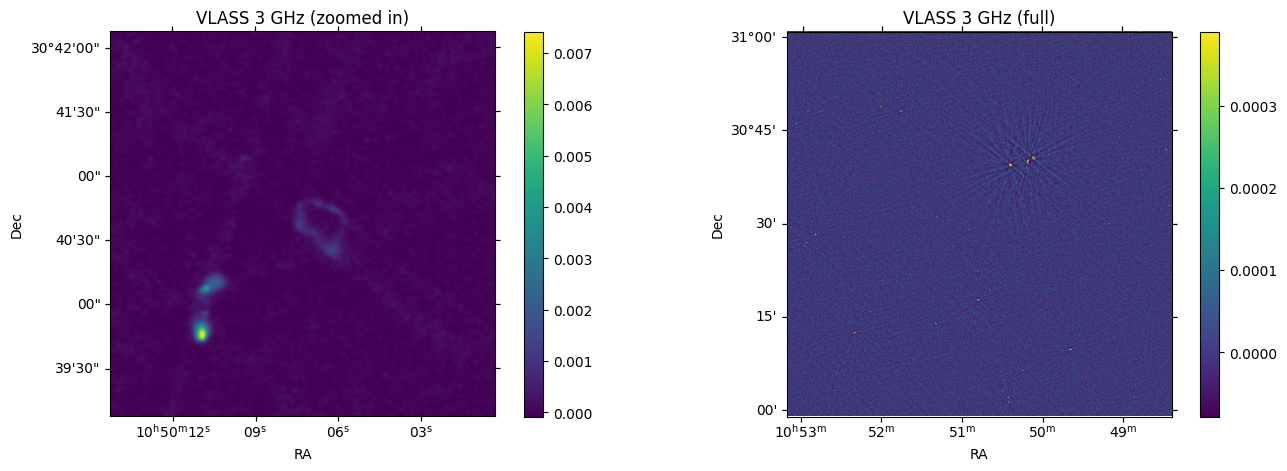

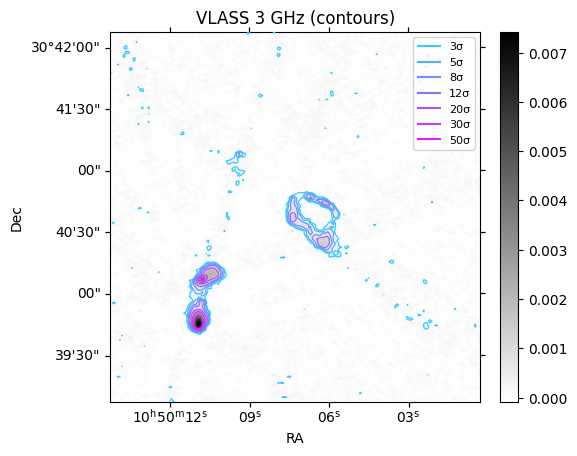

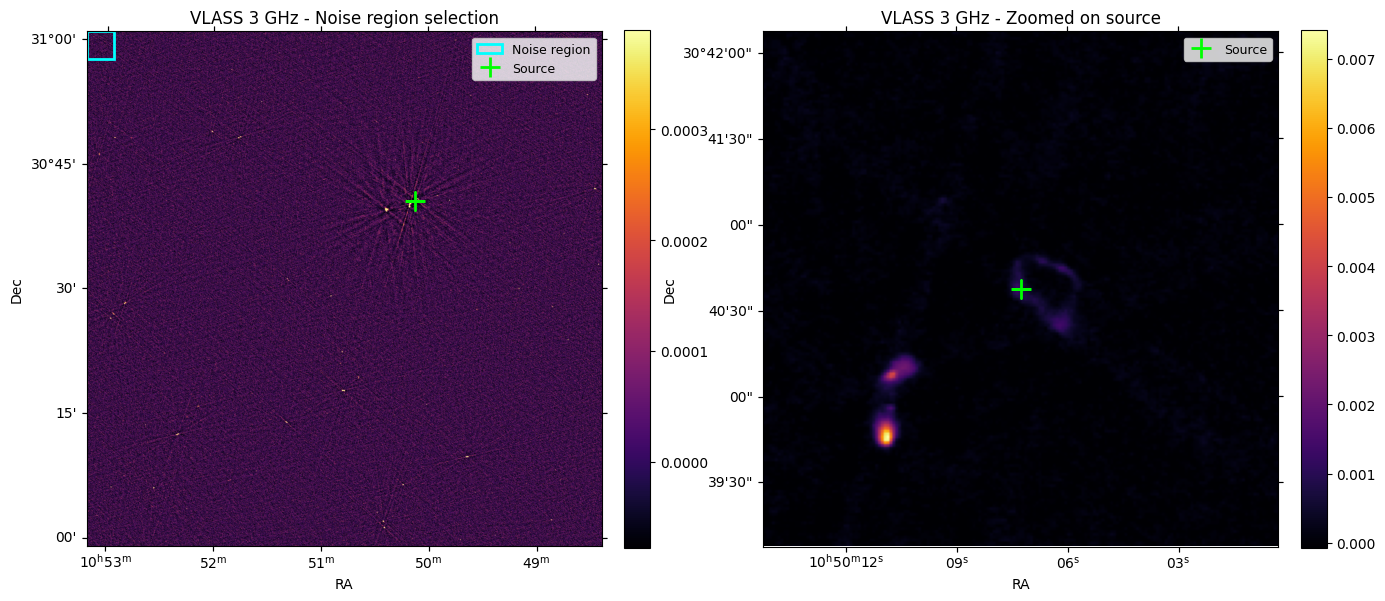

In [4]:
# Step 1: Get source location
x_VLASS, y_VLASS = wcs_VLASS.world_to_pixel(coord)
cutout_VLASS_px = arcsec_to_pixels(wcs_VLASS, cutout_arcsec)
print("Image shape:", data_VLASS.shape)
print("Source pixel location:", x_VLASS, y_VLASS)
print(f"VLASS cutout half-width: {cutout_VLASS_px:.1f} pixels")

# Step 2: RMS and peak
noise_region = data_VLASS[-200:, 0:200]
rms_VLASS = np.nanstd(noise_region)
y_min, y_max = int(y_VLASS - cutout_VLASS_px), int(y_VLASS + cutout_VLASS_px)
x_min, x_max = int(x_VLASS - cutout_VLASS_px), int(x_VLASS + cutout_VLASS_px)
cutout_data = data_VLASS[y_min:y_max, x_min:x_max]
peak_flux_VLASS = np.nanmax(cutout_data)
print(f"RMS: {rms_VLASS}")
print(f"Source peak: {peak_flux_VLASS}")

# Step 3: Make the plots using rms and peak_flux
fig = plt.figure(figsize=(16, 5))

# Zoomed in
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_VLASS)
im1 = ax1.imshow(data_VLASS, origin='lower', cmap='viridis',
                 vmin=-1*rms_VLASS, vmax=peak_flux_VLASS, interpolation="gaussian")
ax1.set_xlim(x_VLASS - cutout_VLASS_px, x_VLASS + cutout_VLASS_px)
ax1.set_ylim(y_VLASS - cutout_VLASS_px, y_VLASS + cutout_VLASS_px)
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('VLASS 3 GHz (zoomed in)')
plt.colorbar(im1, ax=ax1)

# Full image
ax2 = fig.add_subplot(1, 2, 2, projection=wcs_VLASS)
im2 = ax2.imshow(data_VLASS, origin='lower', cmap='viridis',
                 vmin=-1*rms_VLASS, vmax=5*rms_VLASS)
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
ax2.set_title('VLASS 3 GHz (full)')
plt.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.savefig('vlass_cutout.pdf', bbox_inches='tight')
plt.show()

# Step 4: Plot with contours
fig, ax = plt.subplots(subplot_kw={'projection': wcs_VLASS})
im = ax.imshow(data_VLASS, origin='lower', cmap='gray_r',
               vmin=-1*rms_VLASS, vmax=peak_flux_VLASS)
ax.set_xlim(x_VLASS - cutout_VLASS_px, x_VLASS + cutout_VLASS_px)
ax.set_ylim(y_VLASS - cutout_VLASS_px, y_VLASS + cutout_VLASS_px)

# Step 5: Drawing contours at multiple sigma levels
sigma_levels = [3, 5, 8, 12, 20, 30, 50]
levels = [s * rms_VLASS for s in sigma_levels]
colors = cm.cool(np.linspace(0.2, 0.9, len(levels)))
cs = ax.contour(data_VLASS, levels=levels, colors=colors, linewidths=0.9)

# Legend
legend_elements = [
    Line2D([0], [0], color=colors[i], linestyle='solid', label=f'{sigma_levels[i]}σ')
    for i in range(len(levels))
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
plt.title('VLASS 3 GHz (contours)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.savefig('vlass_contours.pdf', bbox_inches='tight')
plt.show()

### Plot for my Methods section: VLASS
fig = plt.figure(figsize=(16, 7))

# Left panel: full image showing where the noise region is
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_VLASS)
im1 = ax1.imshow(data_VLASS, origin='lower', cmap='inferno',
                 vmin=-1*rms_VLASS, vmax=5*rms_VLASS)

# Draw rectangle showing the noise region
noise_box = Rectangle(
    (0, data_VLASS.shape[0] - 200),
    200, 200,
    linewidth=2, edgecolor='cyan', facecolor='none', label='Noise region'
)
ax1.add_patch(noise_box)
# Mark the source position
ax1.plot(x_VLASS, y_VLASS, '+', color='lime', markersize=15, markeredgewidth=2, label='Source')

# Show full image
ax1.set_xlim(0, data_VLASS.shape[1])
ax1.set_ylim(0, data_VLASS.shape[0])
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('VLASS 3 GHz - Noise region selection')
ax1.legend(loc='upper right', fontsize=9)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Right panel: zoomed on source
ax2 = fig.add_subplot(1, 2, 2, projection=wcs_VLASS)
im2 = ax2.imshow(data_VLASS, origin='lower', cmap='inferno',
                 vmin=-1*rms_VLASS, vmax=peak_flux_VLASS)
ax2.set_xlim(x_VLASS - cutout_VLASS_px, x_VLASS + cutout_VLASS_px)
ax2.set_ylim(y_VLASS - cutout_VLASS_px, y_VLASS + cutout_VLASS_px)
ax2.plot(x_VLASS, y_VLASS, '+', color='lime', markersize=15, markeredgewidth=2, label='Source')
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
ax2.set_title('VLASS 3 GHz - Zoomed on source')
ax2.legend(loc='upper right', fontsize=9)
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('vlass_noise_diagnostic.pdf', bbox_inches='tight')
plt.show()

# LoTSS (300 MHz)

Image shape: (200, 200)
Source pixel location: 99.83509458557894 100.38407080304069
LoTSS cutout half-width: 60.0 pixels
RMS: 9.205056135018578e-05
Source peak: 0.14408805335454297


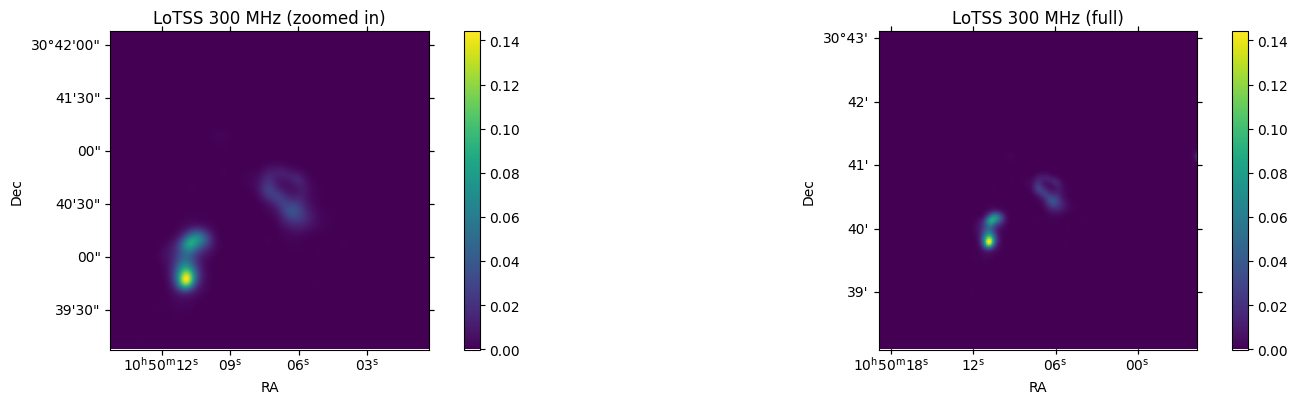

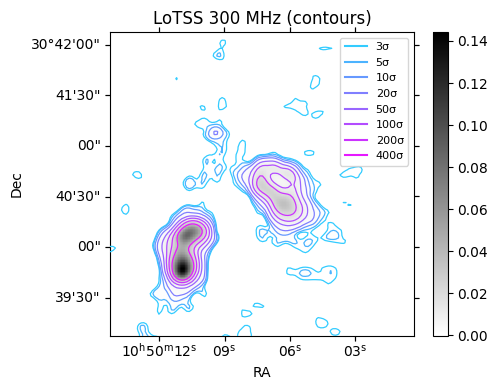

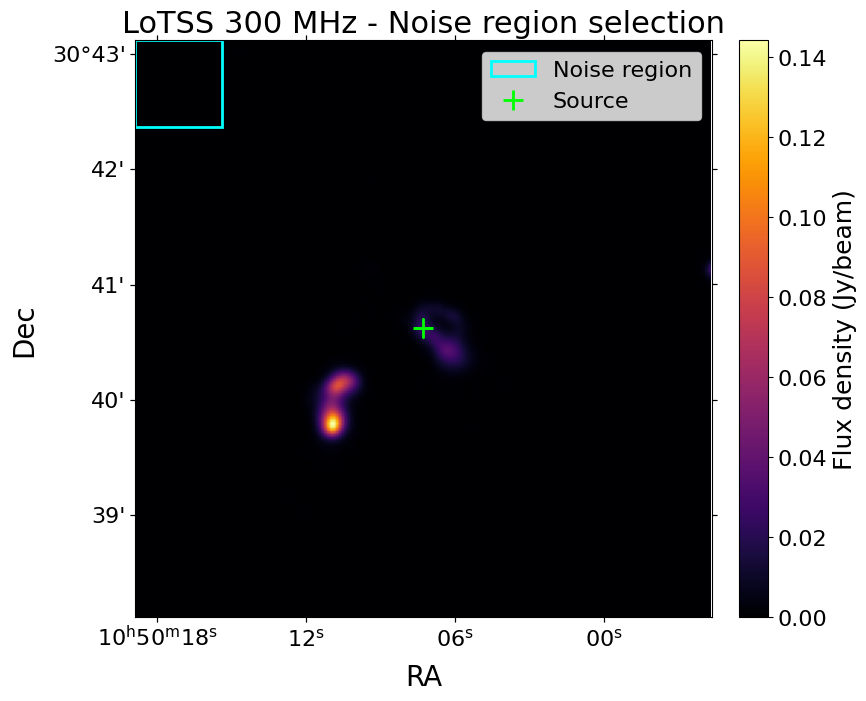

In [5]:
# Step 1: Get source location
x_LOTSS, y_LOTSS = wcs_LOTSS.world_to_pixel(coord)
cutout_LOTSS_px = arcsec_to_pixels(wcs_LOTSS, cutout_arcsec)
print("Image shape:", data_LOTSS.shape)
print("Source pixel location:", x_LOTSS, y_LOTSS)
print(f"LoTSS cutout half-width: {cutout_LOTSS_px:.1f} pixels")

# Step 2: RMS and peak
noise_region = data_LOTSS[-30:, 0:30]
rms_LOTSS = np.nanstd(noise_region)
y_min, y_max = int(y_LOTSS - cutout_LOTSS_px), int(y_LOTSS + cutout_LOTSS_px)
x_min, x_max = int(x_LOTSS - cutout_LOTSS_px), int(x_LOTSS + cutout_LOTSS_px)
cutout_data = data_LOTSS[y_min:y_max, x_min:x_max]
peak_flux_LOTSS = np.nanmax(cutout_data)
print(f"RMS: {rms_LOTSS}")
print(f"Source peak: {peak_flux_LOTSS}")

# Step 3: Make the plots using rms and peak_flux
fig = plt.figure(figsize=(16, 5))

# Zoomed in
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_LOTSS)
im1 = ax1.imshow(data_LOTSS, origin='lower', cmap='viridis',
                 vmin=-1*rms_LOTSS, vmax=peak_flux_LOTSS, interpolation="gaussian")
ax1.set_xlim(x_LOTSS - cutout_LOTSS_px, x_LOTSS + cutout_LOTSS_px)
ax1.set_ylim(y_LOTSS - cutout_LOTSS_px, y_LOTSS + cutout_LOTSS_px)
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('LoTSS 300 MHz (zoomed in)')
plt.colorbar(im1, ax=ax1)

# Full image
ax2 = fig.add_subplot(1, 2, 2, projection=wcs_LOTSS)
im2 = ax2.imshow(data_LOTSS, origin='lower', cmap='viridis',
                 vmin=-1*rms_LOTSS, vmax=peak_flux_LOTSS)
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
ax2.set_title('LoTSS 300 MHz (full)')
plt.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.savefig('lotss_cutout.pdf', bbox_inches='tight')
plt.show()

# Step 4: Plot with contours
fig, ax = plt.subplots(subplot_kw={'projection': wcs_LOTSS})
im = ax.imshow(data_LOTSS, origin='lower', cmap='gray_r',
               vmin=-1*rms_LOTSS, vmax=peak_flux_LOTSS)
ax.set_xlim(x_LOTSS - cutout_LOTSS_px, x_LOTSS + cutout_LOTSS_px)
ax.set_ylim(y_LOTSS - cutout_LOTSS_px, y_LOTSS + cutout_LOTSS_px)

# Step 5: Drawing contours at multiple sigma levels
sigma_levels = [3, 5, 10, 20, 50, 100, 200, 400]
levels = [s * rms_LOTSS for s in sigma_levels]
colors = cm.cool(np.linspace(0.2, 0.9, len(levels)))
cs = ax.contour(data_LOTSS, levels=levels, colors=colors, linewidths=0.9)

# Legend
legend_elements = [
    Line2D([0], [0], color=colors[i], linestyle='solid', label=f'{sigma_levels[i]}σ')
    for i in range(len(levels))
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
plt.title('LoTSS 300 MHz (contours)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('lotss_contours.pdf', bbox_inches='tight')
plt.show()

###Plot for my Methods section: LoTSS
fig = plt.figure(figsize=(16, 7))

# Define the noise region (top-left corner, matching the rms calculation)
noise_y_start, noise_y_end = data_LOTSS.shape[0] - 30, data_LOTSS.shape[0]
noise_x_start, noise_x_end = 0, 30

# Left panel: full image showing where the noise region is
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_LOTSS)
im1 = ax1.imshow(data_LOTSS, origin='lower', cmap='inferno',
                 vmin=-1*rms_LOTSS, vmax=peak_flux_LOTSS)

# Draw rectangle showing the noise region
noise_box = Rectangle(
    (noise_x_start, noise_y_start),
    noise_x_end - noise_x_start,
    noise_y_end - noise_y_start,
    linewidth=2, edgecolor='cyan', facecolor='none', label='Noise region'
)
ax1.add_patch(noise_box)

# Mark the source position
ax1.plot(x_LOTSS, y_LOTSS, '+', color='lime', markersize=15,
         markeredgewidth=2, label='Source')
ax1.set_xlim(0, data_LOTSS.shape[1])
ax1.set_ylim(0, data_LOTSS.shape[0])
ax1.set_xlabel('RA', fontsize=20)
ax1.set_ylabel('Dec', fontsize=20)
ax1.tick_params(axis='both', labelsize=16)
ax1.set_title('LoTSS 300 MHz - Noise region selection', fontsize=22)
ax1.legend(loc='upper right', fontsize=16)
cb1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cb1.ax.tick_params(labelsize=16)
cb1.set_label('Flux density (Jy/beam)', fontsize=18)


# # Right panel: zoomed on source
# ax2 = fig.add_subplot(1, 2, 2, projection=wcs_LOTSS)
# im2 = ax2.imshow(data_LOTSS, origin='lower', cmap='inferno',
#                  vmin=-1*rms_LOTSS, vmax=peak_flux_LOTSS)
# ax2.set_xlim(x_LOTSS - cutout_LOTSS_px, x_LOTSS + cutout_LOTSS_px)
# ax2.set_ylim(y_LOTSS - cutout_LOTSS_px, y_LOTSS + cutout_LOTSS_px)
# ax2.plot(x_LOTSS, y_LOTSS, '+', color='lime', markersize=15, markeredgewidth=2, label='Source')
# ax2.set_xlabel('RA')
# ax2.set_ylabel('Dec')
# ax2.set_title('LoTSS 300 MHz - Zoomed on source')
# ax2.legend(loc='upper right', fontsize=9)
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('lotss_noise_diagnostic.pdf', bbox_inches='tight')
plt.show()

# FIRST (1.4 GHz)

Image shape: (167, 167)
Source pixel location: 83.1786505239092 83.33019717454243
FIRST cutout half-width: 50.0 pixels
RMS: 0.00017903403204400092
Source peak: 0.039059173315763474


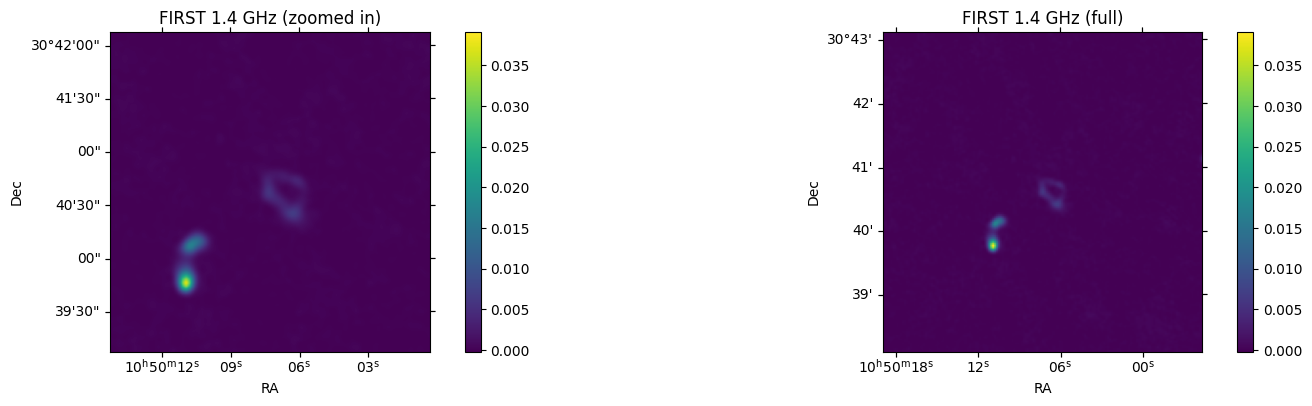

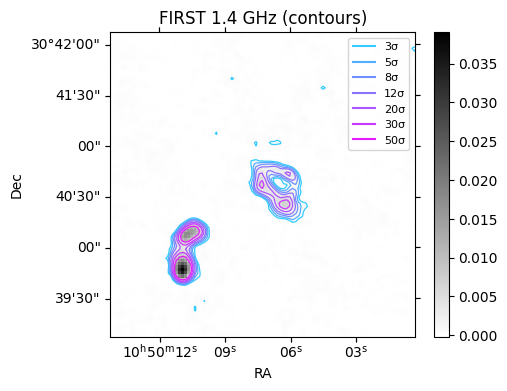

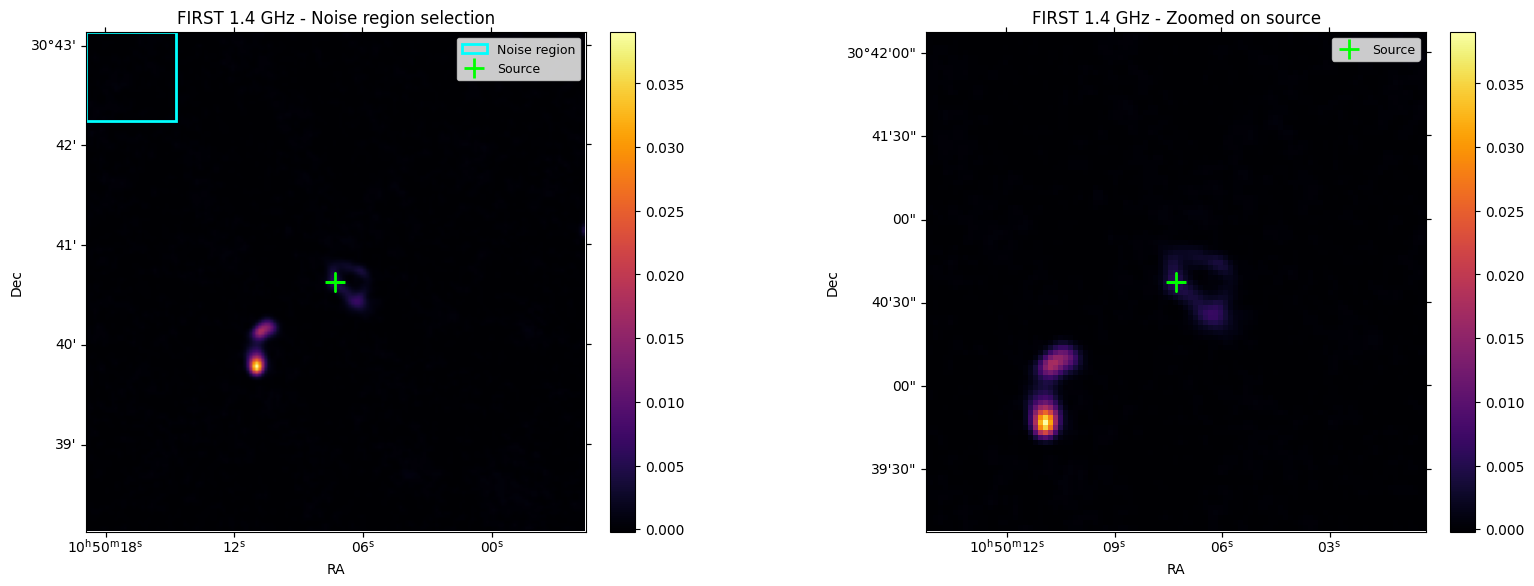

In [6]:
# Step 1: Get source location
x_FIRST, y_FIRST = wcs_FIRST.world_to_pixel(coord)
cutout_FIRST_px = arcsec_to_pixels(wcs_FIRST, cutout_arcsec)
print("Image shape:", data_FIRST.shape)
print("Source pixel location:", x_FIRST, y_FIRST)
print(f"FIRST cutout half-width: {cutout_FIRST_px:.1f} pixels")

# Step 2: RMS and peak

# Choosing the top left to be my representative noise
noise_region = data_FIRST[-30:, 0:30]
rms_FIRST = np.nanstd(noise_region)
y_min, y_max = int(y_FIRST - cutout_FIRST_px), int(y_FIRST + cutout_FIRST_px)
x_min, x_max = int(x_FIRST - cutout_FIRST_px), int(x_FIRST + cutout_FIRST_px)
cutout_data = data_FIRST[y_min:y_max, x_min:x_max]
peak_flux_FIRST = np.nanmax(cutout_data)
print(f"RMS: {rms_FIRST}")
print(f"Source peak: {peak_flux_FIRST}")

# Step 3: Make the plots using rms and peak_flux
fig = plt.figure(figsize=(16, 5))

# Zoomed in
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_FIRST)
im1 = ax1.imshow(data_FIRST, origin='lower', cmap='viridis',
                 vmin=-1*rms_FIRST, vmax=peak_flux_FIRST, interpolation="gaussian")
ax1.set_xlim(x_FIRST - cutout_FIRST_px, x_FIRST + cutout_FIRST_px)
ax1.set_ylim(y_FIRST - cutout_FIRST_px, y_FIRST + cutout_FIRST_px)
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('FIRST 1.4 GHz (zoomed in)')
plt.colorbar(im1, ax=ax1)

# Full image
ax2 = fig.add_subplot(1, 2, 2, projection=wcs_FIRST)
im2 = ax2.imshow(data_FIRST, origin='lower', cmap='viridis',
                 vmin=-1*rms_FIRST, vmax=peak_flux_FIRST)
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
ax2.set_title('FIRST 1.4 GHz (full)')
plt.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.savefig('first_cutout.pdf', bbox_inches='tight')
plt.show()

# Step 4: Plot with contours
fig, ax = plt.subplots(subplot_kw={'projection': wcs_FIRST})
im = ax.imshow(data_FIRST, origin='lower', cmap='gray_r',
               vmin=-1*rms_FIRST, vmax=peak_flux_FIRST)
ax.set_xlim(x_FIRST - cutout_FIRST_px, x_FIRST + cutout_FIRST_px)
ax.set_ylim(y_FIRST - cutout_FIRST_px, y_FIRST + cutout_FIRST_px)

# Step 5: Drawing contours at multiple sigma levels
sigma_levels = [3, 5, 8, 12, 20, 30, 50]
levels = [s * rms_FIRST for s in sigma_levels]
colors = cm.cool(np.linspace(0.2, 0.9, len(levels)))
cs = ax.contour(data_FIRST, levels=levels, colors=colors, linewidths=0.9)

# Legend
legend_elements = [
    Line2D([0], [0], color=colors[i], linestyle='solid', label=f'{sigma_levels[i]}σ')
    for i in range(len(levels))
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
plt.title('FIRST 1.4 GHz (contours)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('first_contours.pdf', bbox_inches='tight')
plt.show()

###Plot for my Methods section: FIRST
fig = plt.figure(figsize=(16, 7))

# Define the noise region (same as what you use for rms calculation)
noise_y_start, noise_y_end = data_FIRST.shape[0] - 30, data_FIRST.shape[0]
noise_x_start, noise_x_end = 0, 30

# Left panel: full image showing where the noise region is
ax1 = fig.add_subplot(1, 2, 1, projection=wcs_FIRST)
im1 = ax1.imshow(data_FIRST, origin='lower', cmap='inferno',
                 vmin=-1*rms_FIRST, vmax=peak_flux_FIRST)

# Draw rectangle showing the noise region
noise_box = Rectangle(
    (noise_x_start, noise_y_start),
    noise_x_end - noise_x_start,
    noise_y_end - noise_y_start,
    linewidth=2, edgecolor='cyan', facecolor='none', label='Noise region'
)
ax1.add_patch(noise_box)

# Mark the source position
ax1.plot(x_FIRST, y_FIRST, '+', color='lime', markersize=15, markeredgewidth=2, label='Source')
ax1.set_xlim(0, data_FIRST.shape[1])
ax1.set_ylim(0, data_FIRST.shape[0])
ax1.set_xlabel('RA')
ax1.set_ylabel('Dec')
ax1.set_title('FIRST 1.4 GHz - Noise region selection')
ax1.legend(loc='upper right', fontsize=9)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# Right panel: zoomed on source
ax2 = fig.add_subplot(1, 2, 2, projection=wcs_FIRST)
im2 = ax2.imshow(data_FIRST, origin='lower', cmap='inferno', 
                 vmin=-1*rms_FIRST, vmax=peak_flux_FIRST)
ax2.set_xlim(x_FIRST - cutout_FIRST_px, x_FIRST + cutout_FIRST_px)
ax2.set_ylim(y_FIRST - cutout_FIRST_px, y_FIRST + cutout_FIRST_px)
ax2.plot(x_FIRST, y_FIRST, '+', color='lime', markersize=15, markeredgewidth=2, label='Source')
ax2.set_xlabel('RA')
ax2.set_ylabel('Dec')
ax2.set_title('FIRST 1.4 GHz - Zoomed on source')
ax2.legend(loc='upper right', fontsize=9)
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('first_noise_diagnostic.pdf', bbox_inches='tight')
plt.show()

## Figures below made specifically for report

#### Comparison figure

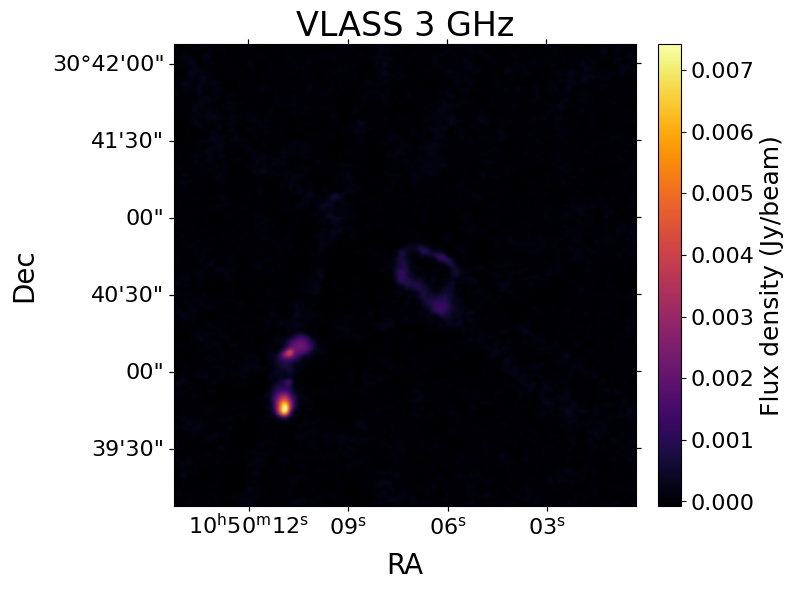

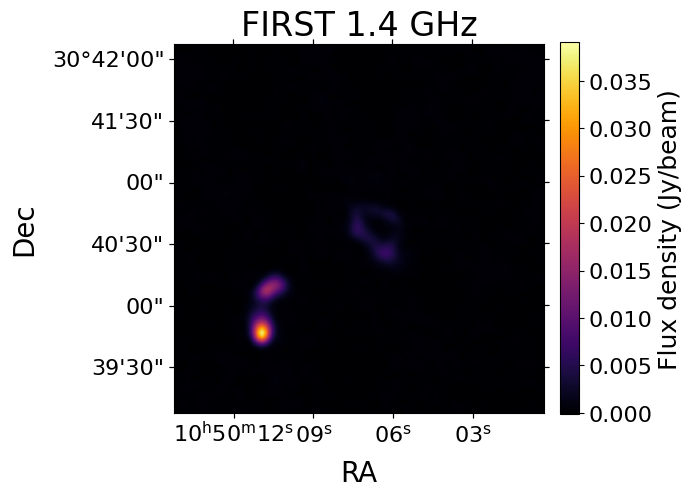

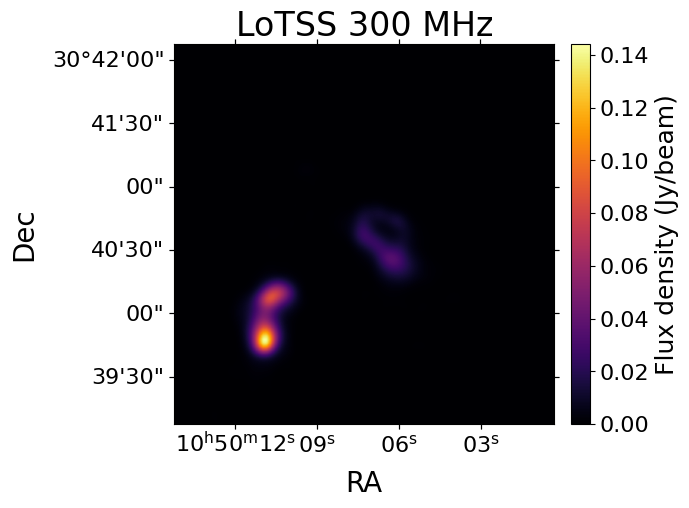

In [7]:
### Three separate cutout figures

# VLASS
fig, ax1 = plt.subplots(figsize=(7, 6), subplot_kw={'projection': wcs_VLASS})
im1 = ax1.imshow(data_VLASS, origin='lower', cmap='inferno',
                 vmin=-1*rms_VLASS, vmax=peak_flux_VLASS,
                 interpolation='gaussian')
ax1.set_xlim(x_VLASS - cutout_VLASS_px, x_VLASS + cutout_VLASS_px)
ax1.set_ylim(y_VLASS - cutout_VLASS_px, y_VLASS + cutout_VLASS_px)
ax1.set_aspect('equal')
ax1.set_xlabel('RA', fontsize=20)
ax1.set_ylabel('Dec', fontsize=20)
ax1.tick_params(axis='both', labelsize=16)
ax1.set_title('VLASS 3 GHz', fontsize=24)
cb1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cb1.ax.tick_params(labelsize=16)
cb1.set_label('Flux density (Jy/beam)', fontsize=18)
plt.tight_layout()
plt.savefig('vlass_panel.pdf', bbox_inches='tight')
plt.show()

# FIRST
fig, ax2 = plt.subplots(figsize=(7, 6), subplot_kw={'projection': wcs_FIRST})
im2 = ax2.imshow(data_FIRST, origin='lower', cmap='inferno',
                 vmin=-1*rms_FIRST, vmax=peak_flux_FIRST,
                 interpolation='gaussian')
ax2.set_xlim(x_FIRST - cutout_FIRST_px, x_FIRST + cutout_FIRST_px)
ax2.set_ylim(y_FIRST - cutout_FIRST_px, y_FIRST + cutout_FIRST_px)
ax2.set_aspect('equal')
ax2.set_xlabel('RA', fontsize=20)
ax2.set_ylabel('Dec', fontsize=20)
ax2.tick_params(axis='both', labelsize=16)
ax2.set_title('FIRST 1.4 GHz', fontsize=24)
cb2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb2.ax.tick_params(labelsize=16)
cb2.set_label('Flux density (Jy/beam)', fontsize=18)
plt.tight_layout()
plt.savefig('first_panel.pdf', bbox_inches='tight')
plt.show()

# LoTSS
fig, ax3 = plt.subplots(figsize=(7, 6), subplot_kw={'projection': wcs_LOTSS})
im3 = ax3.imshow(data_LOTSS, origin='lower', cmap='inferno',
                 vmin=-1*rms_LOTSS, vmax=peak_flux_LOTSS,
                 interpolation='gaussian')
ax3.set_xlim(x_LOTSS - cutout_LOTSS_px, x_LOTSS + cutout_LOTSS_px)
ax3.set_ylim(y_LOTSS - cutout_LOTSS_px, y_LOTSS + cutout_LOTSS_px)
ax3.set_aspect('equal')
ax3.set_xlabel('RA', fontsize=20)
ax3.set_ylabel('Dec', fontsize=20)
ax3.tick_params(axis='both', labelsize=16)
ax3.set_title('LoTSS 300 MHz', fontsize=24)
cb3 = plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cb3.ax.tick_params(labelsize=16)
cb3.set_label('Flux density (Jy/beam)', fontsize=18)
plt.tight_layout()
plt.savefig('lotss_panel.pdf', bbox_inches='tight')
plt.show()

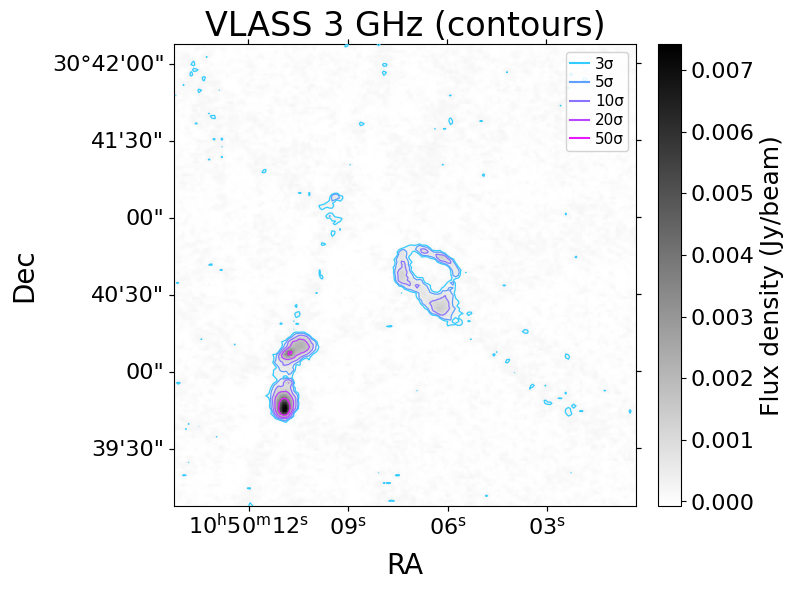

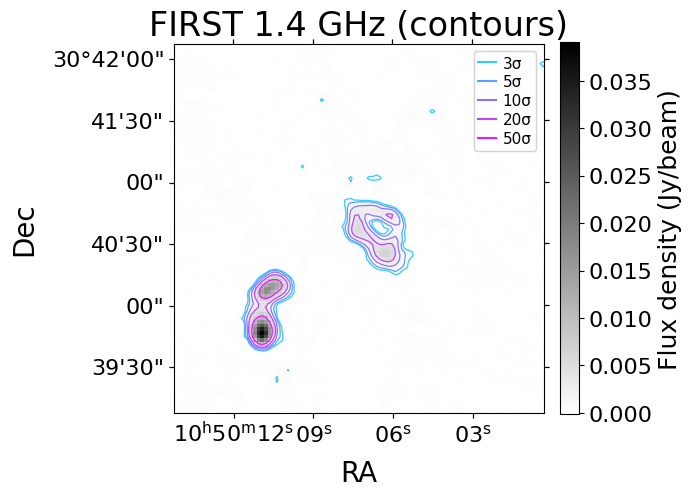

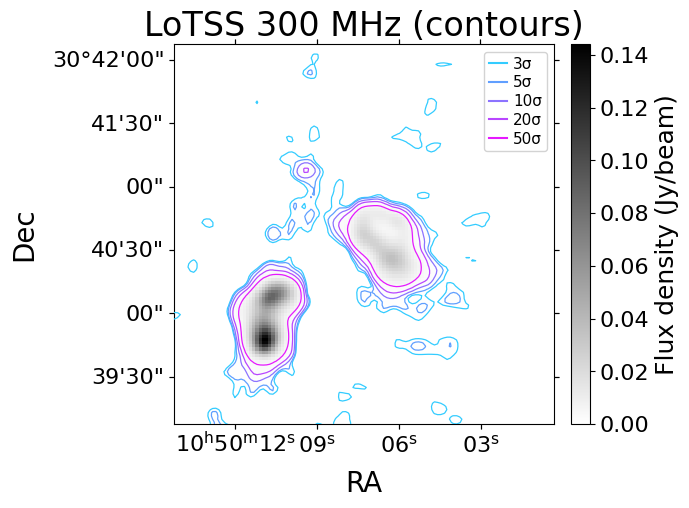

In [8]:
############################# Three separate contour figures

# Shared sigma levels across all surveys
sigma_levels = [3, 5, 10, 20, 50]

# Compact legend settings (shared across all three panels)
legend_kwargs = dict(
    loc='upper right',
    fontsize=11,
    borderpad=0.3,
    labelspacing=0.25,
    handlelength=1.2,
    handletextpad=0.4,
    framealpha=0.85,
)

# VLASS contours
fig, ax1 = plt.subplots(figsize=(7, 6), subplot_kw={'projection': wcs_VLASS})
im1 = ax1.imshow(data_VLASS, origin='lower', cmap='gray_r',
                 vmin=-1*rms_VLASS, vmax=peak_flux_VLASS)
ax1.set_xlim(x_VLASS - cutout_VLASS_px, x_VLASS + cutout_VLASS_px)
ax1.set_ylim(y_VLASS - cutout_VLASS_px, y_VLASS + cutout_VLASS_px)
ax1.set_aspect('equal')
levels = [s * rms_VLASS for s in sigma_levels]
colors = cm.cool(np.linspace(0.2, 0.9, len(levels)))
ax1.contour(data_VLASS, levels=levels, colors=colors, linewidths=0.9)
legend_elements = [
    Line2D([0], [0], color=colors[i], linestyle='solid', label=f'{sigma_levels[i]}σ')
    for i in range(len(levels))
]
ax1.legend(handles=legend_elements, **legend_kwargs)
ax1.set_xlabel('RA', fontsize=20)
ax1.set_ylabel('Dec', fontsize=20)
ax1.tick_params(axis='both', labelsize=16)
ax1.set_title('VLASS 3 GHz (contours)', fontsize=24)
cb1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cb1.ax.tick_params(labelsize=16)
cb1.set_label('Flux density (Jy/beam)', fontsize=18)
plt.tight_layout()
plt.savefig('vlass_contours.pdf', bbox_inches='tight')
plt.show()

# FIRST contours
fig, ax2 = plt.subplots(figsize=(7, 6), subplot_kw={'projection': wcs_FIRST})
im2 = ax2.imshow(data_FIRST, origin='lower', cmap='gray_r',
                 vmin=-1*rms_FIRST, vmax=peak_flux_FIRST)
ax2.set_xlim(x_FIRST - cutout_FIRST_px, x_FIRST + cutout_FIRST_px)
ax2.set_ylim(y_FIRST - cutout_FIRST_px, y_FIRST + cutout_FIRST_px)
ax2.set_aspect('equal')
levels = [s * rms_FIRST for s in sigma_levels]
colors = cm.cool(np.linspace(0.2, 0.9, len(levels)))
ax2.contour(data_FIRST, levels=levels, colors=colors, linewidths=0.9)
legend_elements = [
    Line2D([0], [0], color=colors[i], linestyle='solid', label=f'{sigma_levels[i]}σ')
    for i in range(len(levels))
]
ax2.legend(handles=legend_elements, **legend_kwargs)
ax2.set_xlabel('RA', fontsize=20)
ax2.set_ylabel('Dec', fontsize=20)
ax2.tick_params(axis='both', labelsize=16)
ax2.set_title('FIRST 1.4 GHz (contours)', fontsize=24)
cb2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cb2.ax.tick_params(labelsize=16)
cb2.set_label('Flux density (Jy/beam)', fontsize=18)
plt.tight_layout()
plt.savefig('first_contours.pdf', bbox_inches='tight')
plt.show()

# LoTSS contours
fig, ax3 = plt.subplots(figsize=(7, 6), subplot_kw={'projection': wcs_LOTSS})
im3 = ax3.imshow(data_LOTSS, origin='lower', cmap='gray_r',
                 vmin=-1*rms_LOTSS, vmax=peak_flux_LOTSS)
ax3.set_xlim(x_LOTSS - cutout_LOTSS_px, x_LOTSS + cutout_LOTSS_px)
ax3.set_ylim(y_LOTSS - cutout_LOTSS_px, y_LOTSS + cutout_LOTSS_px)
ax3.set_aspect('equal')
levels = [s * rms_LOTSS for s in sigma_levels]
colors = cm.cool(np.linspace(0.2, 0.9, len(levels)))
ax3.contour(data_LOTSS, levels=levels, colors=colors, linewidths=0.9)
legend_elements = [
    Line2D([0], [0], color=colors[i], linestyle='solid', label=f'{sigma_levels[i]}σ')
    for i in range(len(levels))
]
ax3.legend(handles=legend_elements, **legend_kwargs)
ax3.set_xlabel('RA', fontsize=20)
ax3.set_ylabel('Dec', fontsize=20)
ax3.tick_params(axis='both', labelsize=16)
ax3.set_title('LoTSS 300 MHz (contours)', fontsize=24)
cb3 = plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cb3.ax.tick_params(labelsize=16)
cb3.set_label('Flux density (Jy/beam)', fontsize=18)
plt.tight_layout()
plt.savefig('lotss_contours.pdf', bbox_inches='tight')
plt.show()